In [1]:
import re

text = """
residue id #6/A:275 name SER index 25
residue id #6/A:276 name GLY index 26
residue id #6/A:277 name GLY index 27
residue id #6/A:336 name THR index 86
residue id #6/A:337 name SER index 87
residue id #6/A:338 name ASP index 88
residue id #6/A:339 name ASP index 89
residue id #6/A:342 name GLU index 92
residue id #6/A:375 name GLU index 125
residue id #6/A:379 name GLU index 129
residue id #6/A:382 name ARG index 132
residue id #6/A:416 name LYS index 166
residue id #6/A:451 name THR index 201
residue id #6/A:452 name LEU index 202
residue id #6/A:453 name ARG index 203
residue id #6/A:454 name TYR index 204
residue id #6/A:483 name HIS index 233
residue id #6/A:486 name ASP index 236
residue id #6/A:487 name THR index 237
residue id #6/A:488 name ALA index 238
residue id #6/A:489 name PHE index 239
residue id #6/A:490 name GLU index 240
residue id #6/A:492 name SER index 242
residue id #6/A:493 name LYS index 243
residue id #6/A:495 name PHE index 245
residue id #6/A:496 name THR index 246
residue id #6/A:499 name ARG index 249
"""

# Extract every integer that immediately follows a ":"
residues = [int(n) for n in re.findall(r':(\d+)', text)]

print(residues)

[275, 276, 277, 336, 337, 338, 339, 342, 375, 379, 382, 416, 451, 452, 453, 454, 483, 486, 487, 488, 489, 490, 492, 493, 495, 496, 499]


In [9]:
#!/usr/bin/env python3
"""
Align lists of integers similar to a protein sequence alignment.
Each position shows which sequences contain that integer, with gaps for missing values.
"""

def align_integer_lists(sequences, names):
    """
    Create a sequence alignment-style visualization of integer lists.
    
    Args:
        sequences: list of lists of integers
        names: list of sequence names
    
    Returns:
        formatted alignment string
    """
    # Get all unique integers across all sequences and sort them
    all_integers = sorted(set(num for seq in sequences for num in seq))
    
    # Create alignment matrix
    alignment = []
    for name, seq in zip(names, sequences):
        seq_set = set(seq)
        aligned_seq = []
        for pos in all_integers:
            if pos in seq_set:
                aligned_seq.append(str(pos))
            else:
                aligned_seq.append('---')  # gap representation
        alignment.append((name, aligned_seq))
    
    # Format output
    max_name_len = max(len(name) for name in names)
    lines = []
    
    # Header with position numbers (every 10th position)
    header_nums = []
    header_marks = []
    for i, pos in enumerate(all_integers):
        if i % 10 == 0:
            header_nums.append(f"{i+1:>3}")
            header_marks.append(" | ")
        else:
            header_nums.append("   ")
            header_marks.append("   ")
    
    lines.append(" " * (max_name_len + 2) + "".join(header_nums))
    lines.append(" " * (max_name_len + 2) + "".join(header_marks))
    
    # Position ruler (actual residue numbers)
    pos_line = " " * (max_name_len + 2)
    for i, pos in enumerate(all_integers):
        pos_line += f"{pos:>3}"
    lines.append(pos_line)
    lines.append("")
    
    # Sequence alignments
    for name, aligned_seq in alignment:
        seq_line = f"{name:<{max_name_len}}: " + "".join(f"{x:>3}" for x in aligned_seq)
        lines.append(seq_line)
    
    return "\n".join(lines)

# Your data
eIF2a = [274, 275, 276, 279, 335, 337, 338, 339, 340, 341, 342, 379, 382, 451, 452, 453, 483, 486, 487, 488, 489, 490, 491, 492, 493]
vacv = [278, 339, 375, 379, 382, 414, 416, 435, 448, 449, 450, 451, 452, 453, 455, 460, 486, 487, 488, 489, 490, 492, 493, 496]
varv = [278, 339, 375, 379, 382, 414, 416, 435, 448, 449, 450, 451, 452, 453, 455, 460, 486, 487, 488, 489, 490, 492, 493, 496]
tpv = [276, 277, 278, 375, 379, 382, 414, 416, 418, 435, 448, 450, 451, 452, 453, 454, 455, 480, 486, 487, 488, 489, 490, 491, 492, 493, 496]
myxv = [275, 277, 278, 304, 335, 337, 339, 375, 376, 414, 416, 434, 435, 448, 450, 451, 452, 453, 454, 455, 486, 487, 488, 489, 490, 492]
rcv = [275, 276, 277, 336, 337, 338, 339, 342, 375, 379, 382, 416, 451, 452, 453, 454, 483, 486, 487, 488, 489, 490, 492, 493, 495, 496, 499]

sequences = [eIF2a, vacv, varv, tpv, myxv, rcv]
names = ['eIF2a', 'vacv', 'varv', 'tpv', 'myxv', 'rcv']

# Generate and print alignment
alignment = align_integer_lists(sequences, names)
print(alignment)

# Also generate a compact version showing only conserved positions
print("\n" + "="*80)
print("CONSERVED POSITIONS (present in all sequences):")
print("="*80)

all_seqs = [set(seq) for seq in sequences]
conserved = set.intersection(*all_seqs)
conserved_sorted = sorted(conserved)

print(f"Conserved across all 6 sequences: {conserved_sorted}")
print(f"Total conserved positions: {len(conserved_sorted)}")

# Show positions present in at least N sequences
for min_seqs in [5, 4, 3]:
    shared = []
    for pos in sorted(set(num for seq in sequences for num in seq)):
        count = sum(1 for seq in sequences if pos in set(seq))
        if count >= min_seqs:
            shared.append(pos)
    print(f"Present in >={min_seqs} sequences: {shared} ({len(shared)} positions)")


         1                            11                            21                            31                            41               
        |                             |                             |                             |                             |                
       274275276277278279304335336337338339340341342375376379382414416418434435448449450451452453454455460480483486487488489490491492493495496499

eIF2a: 274275276------279---335---337338339340341342------379382------------------------451452453------------483486487488489490491492493---------
vacv : ------------278------------------339---------375---379382414416------435448449450451452453---455460------486487488489490---492493---496---
varv : ------------278------------------339---------375---379382414416------435448449450451452453---455460------486487488489490---492493---496---
tpv  : ------276277278------------------------------375---379382414416418---435448---450451452453454455---480---48648748848

In [13]:
eIF2a = {274, 275, 276, 279, 335, 337, 338, 339, 340, 341, 342, 379, 382, 451, 452, 453, 483, 486, 487, 488, 489, 490, 491, 492, 493}
vacv = {278, 339, 375, 379, 382, 414, 416, 435, 448, 449, 450, 451, 452, 453, 455, 460, 486, 487, 488, 489, 490, 492, 493, 496}
varv = {278, 339, 375, 379, 382, 414, 416, 435, 448, 449, 450, 451, 452, 453, 455, 460, 486, 487, 488, 489, 490, 492, 493, 496}
tpv = {276, 277, 278, 375, 379, 382, 414, 416, 418, 435, 448, 450, 451, 452, 453, 454, 455, 480, 486, 487, 488, 489, 490, 491, 492, 493, 496}
myxv = {275, 277, 278, 304, 335, 337, 339, 375, 376, 414, 416, 434, 435, 448, 450, 451, 452, 453, 454, 455, 486, 487, 488, 489, 490, 492}
rcv = {275, 276, 277, 336, 337, 338, 339, 342, 375, 379, 382, 416, 451, 452, 453, 454, 483, 486, 487, 488, 489, 490, 492, 493, 495, 496, 499}

a_union = list(set.union(eIF2a,vacv,varv,tpv,myxv,rcv))
a_union


[274,
 275,
 276,
 277,
 278,
 279,
 414,
 416,
 418,
 304,
 434,
 435,
 448,
 449,
 450,
 451,
 452,
 453,
 454,
 455,
 460,
 335,
 336,
 337,
 338,
 339,
 340,
 341,
 342,
 480,
 483,
 486,
 487,
 488,
 489,
 490,
 491,
 492,
 493,
 495,
 496,
 499,
 375,
 376,
 379,
 382]

In [ ]:
CONTACT_TRACK_DICT = {
  "eIF2a":{
      "label":"eIF2α Contact", 
      "color":"gray", 
      "sites":[274, 275, 276, 279, 335, 337, 338, 339, 340, 341, 342, 379, 382, 451, 452, 453, 483, 486, 487, 488, 489, 490, 491, 492, 493]
  },
  "vacv":{
    "label":"Vaccinia K3 Contact", 
    "color":"#786BAC", 
    "sites":[278, 339, 375, 379, 382, 414, 416, 435, 448, 449, 450, 451, 452, 453, 455, 460, 486, 487, 488, 489, 490, 492, 493, 496]
    },
  "varv":{
    "label":"Variola K3 Contact", 
    "color":"#E86562", 
    "sites":[278, 339, 375, 379, 382, 414, 416, 435, 448, 449, 450, 451, 452, 453, 455, 460, 486, 487, 488, 489, 490, 492, 493, 496]
    },
  "tpv":{
    "label":"Tanapox K3 Contact", 
    "color":"#F4B681", 
    "sites":[276, 277, 278, 375, 379, 382, 414, 416, 418, 435, 448, 450, 451, 452, 453, 454, 455, 480, 486, 487, 488, 489, 490, 491, 492, 493, 496]
    },
  "myxv":{
    "label":"Myxoma K3 Contact", 
    "color":"#6BB3FC", 
    "sites":[275, 277, 278, 304, 335, 337, 339, 375, 376, 414, 416, 434, 435, 448, 450, 451, 452, 453, 454, 455, 486, 487, 488, 489, 490, 492]
    },
  "rcv":{
    "label":"Ranavirus vIF2α Contact", 
    "color":"#A8D39B", 
    "sites":[275, 276, 277, 336, 337, 338, 339, 342, 375, 379, 382, 416, 451, 452, 453, 454, 483, 486, 487, 488, 489, 490, 492, 493, 495, 496, 499]
    },
  "conserved":{
    "label":"Conserved Site", 
    "color":"black", 
    "sites":[263, 267, 276, 277, 278, 279, 281, 283, 296, 298, 308, 309, 312, 315, 317, 319, 320, 323, 327, 362, 364, 365, 366, 367, 369, 374, 377, 397, 401, 404, 406, 407, 410, 411, 412, 413, 414, 415, 416, 417, 419, 420, 429, 430, 431, 432, 433, 437, 444, 445, 446, 450, 451, 454, 455, 457, 458, 459, 465, 469, 470, 474, 475, 476, 477, 480, 490, 511, 519, 523, 526]
    },
  "positive_vert":{
    "label":"Positive Selection", 
    "color":"red", 
    "sites":[261, 269, 270, 271, 272, 307, 314, 322, 360, 368, 375, 378, 379, 382, 385, 389, 394, 405, 428, 448, 449, 462, 471, 483, 486, 488, 491, 493, 500, 502, 504, 505, 514, 520, 524]
    }
}

CONTACT_TRACK_LIST = {
  "K3Δ58":["eIF2a","vacv","conserved","positive_vert"],
  "VACV K3":["eIF2a","vacv","conserved","positive_vert"],
  "VARV C3":["eIF2a","varv","conserved","positive_vert"],
  "TPV K3":["eIF2a","tpv","conserved","positive_vert"],
  "MYXV M156R":["eIF2a","myxv","conserved","positive_vert"],
  "RCVZ vIF2α":["eIF2a","rcv","conserved","positive_vert"],
}

In [2]:
# from the chimerax residues now get a list of integers and the WT AA

chimerax_data = """
residue id #1/A:274 name GLY index 24
residue id #1/A:275 name SER index 25
residue id #1/A:276 name GLY index 26
residue id #1/A:277 name GLY index 27
residue id #1/A:278 name PHE index 28
residue id #1/A:279 name GLY index 29
residue id #1/A:304 name LYS index 54
residue id #1/A:335 name GLU index 85
residue id #1/A:336 name THR index 86
residue id #1/A:337 name SER index 87
residue id #1/A:338 name ASP index 88
residue id #1/A:339 name ASP index 89
residue id #1/A:340 name SER index 90
residue id #1/A:341 name LEU index 91
residue id #1/A:342 name GLU index 92
residue id #1/A:375 name GLU index 125
residue id #1/A:376 name GLN index 126
residue id #1/A:379 name GLU index 129
residue id #1/A:382 name ARG index 132
residue id #1/A:414 name ASP index 164
residue id #1/A:416 name LYS index 166
residue id #1/A:418 name SER index 168
residue id #1/A:434 name GLY index 184
residue id #1/A:435 name LEU index 185
residue id #1/A:448 name SER index 198
residue id #1/A:449 name LYS index 199
residue id #1/A:450 name GLY index 200
residue id #1/A:451 name THR index 201
residue id #1/A:452 name LEU index 202
residue id #1/A:453 name ARG index 203
residue id #1/A:454 name TYR index 204
residue id #1/A:455 name MET index 205
residue id #1/A:460 name ILE index 210
residue id #1/A:480 name GLU index 230
residue id #1/A:483 name HIS index 233
residue id #1/A:486 name ASP index 236
residue id #1/A:487 name THR index 237
residue id #1/A:488 name ALA index 238
residue id #1/A:489 name PHE index 239
residue id #1/A:490 name GLU index 240
residue id #1/A:491 name THR index 241
residue id #1/A:492 name SER index 242
residue id #1/A:493 name LYS index 243
residue id #1/A:495 name PHE index 245
residue id #1/A:496 name THR index 246
residue id #1/A:499 name ARG index 249
"""

matches = re.findall(r':(\d+) name ([A-Z]{3})', chimerax_data)

residue_position = [int(m[0]) for m in matches]
residue_aa = [m[1] for m in matches]


In [3]:
residue_aa

['GLY',
 'SER',
 'GLY',
 'GLY',
 'PHE',
 'GLY',
 'LYS',
 'GLU',
 'THR',
 'SER',
 'ASP',
 'ASP',
 'SER',
 'LEU',
 'GLU',
 'GLU',
 'GLN',
 'GLU',
 'ARG',
 'ASP',
 'LYS',
 'SER',
 'GLY',
 'LEU',
 'SER',
 'LYS',
 'GLY',
 'THR',
 'LEU',
 'ARG',
 'TYR',
 'MET',
 'ILE',
 'GLU',
 'HIS',
 'ASP',
 'THR',
 'ALA',
 'PHE',
 'GLU',
 'THR',
 'SER',
 'LYS',
 'PHE',
 'THR',
 'ARG']

In [4]:
residue_position

[274,
 275,
 276,
 277,
 278,
 279,
 304,
 335,
 336,
 337,
 338,
 339,
 340,
 341,
 342,
 375,
 376,
 379,
 382,
 414,
 416,
 418,
 434,
 435,
 448,
 449,
 450,
 451,
 452,
 453,
 454,
 455,
 460,
 480,
 483,
 486,
 487,
 488,
 489,
 490,
 491,
 492,
 493,
 495,
 496,
 499]

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import ListedColormap
import matplotlib.patches as patches
import os

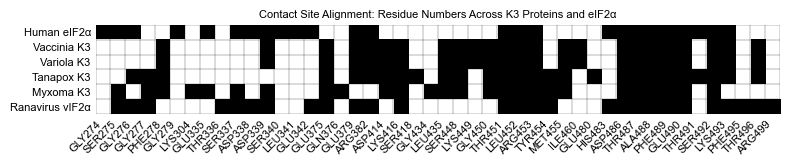

Conservation Analysis:
Conserved across all 6 sequences: [451, 452, 453, 486, 487, 488, 489, 490, 492]
Total conserved positions: 9
Present in >=5 sequences: [339, 375, 379, 382, 416, 451, 452, 453, 486, 487, 488, 489, 490, 492, 493] (15 positions)
Present in >=4 sequences: [278, 339, 375, 379, 382, 414, 416, 435, 448, 450, 451, 452, 453, 455, 486, 487, 488, 489, 490, 492, 493, 496] (22 positions)
Present in >=3 sequences: [275, 276, 277, 278, 337, 339, 375, 379, 382, 414, 416, 435, 448, 450, 451, 452, 453, 454, 455, 486, 487, 488, 489, 490, 492, 493, 496] (27 positions)

Detailed Position Analysis:
GLY274: Human eIF2α
SER275: Ranavirus vIF2α, Myxoma K3, Human eIF2α
GLY276: Ranavirus vIF2α, Tanapox K3, Human eIF2α
GLY277: Ranavirus vIF2α, Myxoma K3, Tanapox K3
PHE278: Myxoma K3, Tanapox K3, Variola K3, Vaccinia K3
GLY279: Human eIF2α
LYS304: Myxoma K3
GLU335: Myxoma K3, Human eIF2α
THR336: Ranavirus vIF2α
SER337: Ranavirus vIF2α, Myxoma K3, Human eIF2α
ASP338: Ranavirus vIF2α, Human eI

In [23]:
# contacts heatmap

# figure save directory
save_dir = "../../img/heatmaps"
os.makedirs(save_dir, exist_ok=True)

# Set up matplotlib parameters
plt.rcParams['font.family'] = 'Arial'

# Your data
eIF2a = [274, 275, 276, 279, 335, 337, 338, 339, 340, 341, 342, 379, 382, 451, 452, 453, 483, 486, 487, 488, 489, 490, 491, 492, 493]
vacv = [278, 339, 375, 379, 382, 414, 416, 435, 448, 449, 450, 451, 452, 453, 455, 460, 486, 487, 488, 489, 490, 492, 493, 496]
varv = [278, 339, 375, 379, 382, 414, 416, 435, 448, 449, 450, 451, 452, 453, 455, 460, 486, 487, 488, 489, 490, 492, 493, 496]
tpv = [276, 277, 278, 375, 379, 382, 414, 416, 418, 435, 448, 450, 451, 452, 453, 454, 455, 480, 486, 487, 488, 489, 490, 491, 492, 493, 496]
myxv = [275, 277, 278, 304, 335, 337, 339, 375, 376, 414, 416, 434, 435, 448, 450, 451, 452, 453, 454, 455, 486, 487, 488, 489, 490, 492]
rcv = [275, 276, 277, 336, 337, 338, 339, 342, 375, 379, 382, 416, 451, 452, 453, 454, 483, 486, 487, 488, 489, 490, 492, 493, 495, 496, 499]

residue_positions = [274, 275, 276, 277, 278, 279, 304, 335, 336, 337, 338, 339, 340, 341, 342, 375, 376, 379, 382, 414, 416, 418, 434, 435, 448, 449, 450, 451, 452, 453, 454, 455, 460, 480, 483, 486, 487, 488, 489, 490, 491, 492, 493, 495, 496, 499]
residue_aas = ['GLY', 'SER', 'GLY', 'GLY', 'PHE', 'GLY', 'LYS', 'GLU', 'THR', 'SER', 'ASP', 'ASP', 'SER', 'LEU', 'GLU', 'GLU', 'GLN', 'GLU', 'ARG', 'ASP', 'LYS', 'SER', 'GLY', 'LEU', 'SER', 'LYS', 'GLY', 'THR', 'LEU', 'ARG', 'TYR', 'MET', 'ILE', 'GLU', 'HIS', 'ASP', 'THR', 'ALA', 'PHE', 'GLU', 'THR', 'SER', 'LYS', 'PHE', 'THR', 'ARG']

sequences = [eIF2a, vacv, varv, tpv, myxv, rcv]
sequences.reverse()
names = ['Human eIF2α', 'Vaccinia K3', 'Variola K3', 'Tanapox K3', 'Myxoma K3', 'Ranavirus vIF2α']
names.reverse()

# Create alignment matrix showing actual residue numbers (not binary)
alignment_matrix = []
for seq in sequences:
    seq_set = set(seq)
    row = []
    for pos in residue_positions:
        if pos in seq_set:
            row.append(pos)  # Show actual residue number
        else:
            row.append(np.nan)  # Use NaN for missing positions
    alignment_matrix.append(row)

# Create DataFrame
df = pd.DataFrame(alignment_matrix, index=names, columns=residue_positions)

# Create column labels combining AA and position
column_labels = [f"{aa}{pos}" for aa, pos in zip(residue_aas, residue_positions)]

# Set up the figure
fig, ax = plt.subplots(figsize=(8, 4))

# Create a custom colormap for the residue numbers
# We'll use a colormap that maps each unique residue number to a color
# For simplicity, we'll use a grayscale approach where presence = black, absence = white
display_matrix = []
for row in alignment_matrix:
    display_row = []
    for val in row:
        if pd.isna(val):
            display_row.append(0)  # White for missing
        else:
            display_row.append(1)  # Black for present
    display_matrix.append(display_row)

display_matrix = np.array(display_matrix)

# Create colormap: 0 -> white, 1 -> black
colors = ['white', 'black']
cmap = ListedColormap(colors)

# Plot the base heatmap
im = ax.imshow(display_matrix, cmap=cmap, aspect='equal', vmin=0, vmax=1)



# Set ticks and labels
ax.set_xticks(range(len(column_labels)))
ax.set_yticks(range(len(names)))
ax.set_xticklabels(column_labels, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(names, fontsize=8)

# Add 0.2 pt grid lines around each cell
for i in range(len(names) + 1):
    ax.axhline(i - 0.5, color='black', linewidth=0.2)
for j in range(len(column_labels) + 1):
    ax.axvline(j - 0.5, color='black', linewidth=0.2)

# Remove default spines
for spine in ax.spines.values():
    spine.set_visible(False)

# Set limits
ax.set_xlim(-0.5, len(column_labels) - 0.5)
ax.set_ylim(-0.5, len(names) - 0.5)

# Remove ticks (keep labels)
ax.tick_params(length=0)

# Adjust layout
plt.tight_layout()

# Add title
plt.title('Contact Site Alignment: Residue Numbers Across K3 Proteins and eIF2α', fontsize=8, pad=5)

# Save the figure
plot_name = 'substrate-contacts-to-pkr.svg'
output_file = os.path.join(save_dir, plot_name)
plt.savefig(output_file, bbox_inches='tight', format='svg', facecolor='white', edgecolor='none', transparent=True)

plt.show()

###

# Print conservation analysis
print("Conservation Analysis:")
print("=" * 50)

all_seqs = [set(seq) for seq in sequences]
conserved = set.intersection(*all_seqs)
conserved_sorted = sorted(conserved)

print(f"Conserved across all 6 sequences: {conserved_sorted}")
print(f"Total conserved positions: {len(conserved_sorted)}")

# Show positions present in at least N sequences
for min_seqs in [5, 4, 3]:
    shared = []
    for pos in sorted(set(num for seq in sequences for num in seq)):
        count = sum(1 for seq in sequences if pos in set(seq))
        if count >= min_seqs:
            shared.append(pos)
    print(f"Present in >={min_seqs} sequences: {shared} ({len(shared)} positions)")

# Create a summary showing which sequences share each position
print("\nDetailed Position Analysis:")
print("=" * 50)
for pos in sorted(set(num for seq in sequences for num in seq)):
    present_in = [names[i] for i, seq in enumerate(sequences) if pos in set(seq)]
    aa = residue_aas[residue_positions.index(pos)]
    print(f"{aa}{pos}: {', '.join(present_in)}")

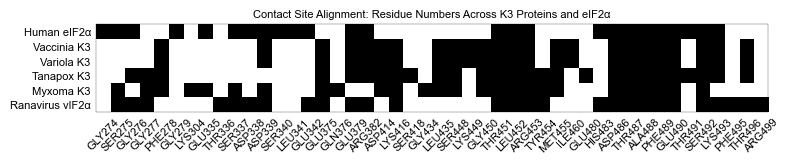

Conservation Analysis:
Conserved across all 6 sequences: [451, 452, 453, 486, 487, 488, 489, 490, 492]
Total conserved positions: 9
Present in >=5 sequences: [339, 375, 379, 382, 416, 451, 452, 453, 486, 487, 488, 489, 490, 492, 493] (15 positions)
Present in >=4 sequences: [278, 339, 375, 379, 382, 414, 416, 435, 448, 450, 451, 452, 453, 455, 486, 487, 488, 489, 490, 492, 493, 496] (22 positions)
Present in >=3 sequences: [275, 276, 277, 278, 337, 339, 375, 379, 382, 414, 416, 435, 448, 450, 451, 452, 453, 454, 455, 486, 487, 488, 489, 490, 492, 493, 496] (27 positions)

Detailed Position Analysis:
GLY274: Human eIF2α
SER275: Ranavirus vIF2α, Myxoma K3, Human eIF2α
GLY276: Ranavirus vIF2α, Tanapox K3, Human eIF2α
GLY277: Ranavirus vIF2α, Myxoma K3, Tanapox K3
PHE278: Myxoma K3, Tanapox K3, Variola K3, Vaccinia K3
GLY279: Human eIF2α
LYS304: Myxoma K3
GLU335: Myxoma K3, Human eIF2α
THR336: Ranavirus vIF2α
SER337: Ranavirus vIF2α, Myxoma K3, Human eIF2α
ASP338: Ranavirus vIF2α, Human eI

In [30]:
# contacts heatmap

# figure save directory
save_dir = "../../img/heatmaps"
os.makedirs(save_dir, exist_ok=True)

# Set up matplotlib parameters
plt.rcParams['font.family'] = 'Arial'

# Your data
eIF2a = [274, 275, 276, 279, 335, 337, 338, 339, 340, 341, 342, 379, 382, 451, 452, 453, 483, 486, 487, 488, 489, 490, 491, 492, 493]
vacv = [278, 339, 375, 379, 382, 414, 416, 435, 448, 449, 450, 451, 452, 453, 455, 460, 486, 487, 488, 489, 490, 492, 493, 496]
varv = [278, 339, 375, 379, 382, 414, 416, 435, 448, 449, 450, 451, 452, 453, 455, 460, 486, 487, 488, 489, 490, 492, 493, 496]
tpv = [276, 277, 278, 375, 379, 382, 414, 416, 418, 435, 448, 450, 451, 452, 453, 454, 455, 480, 486, 487, 488, 489, 490, 491, 492, 493, 496]
myxv = [275, 277, 278, 304, 335, 337, 339, 375, 376, 414, 416, 434, 435, 448, 450, 451, 452, 453, 454, 455, 486, 487, 488, 489, 490, 492]
rcv = [275, 276, 277, 336, 337, 338, 339, 342, 375, 379, 382, 416, 451, 452, 453, 454, 483, 486, 487, 488, 489, 490, 492, 493, 495, 496, 499]

residue_positions = [274, 275, 276, 277, 278, 279, 304, 335, 336, 337, 338, 339, 340, 341, 342, 375, 376, 379, 382, 414, 416, 418, 434, 435, 448, 449, 450, 451, 452, 453, 454, 455, 460, 480, 483, 486, 487, 488, 489, 490, 491, 492, 493, 495, 496, 499]
residue_aas = ['GLY', 'SER', 'GLY', 'GLY', 'PHE', 'GLY', 'LYS', 'GLU', 'THR', 'SER', 'ASP', 'ASP', 'SER', 'LEU', 'GLU', 'GLU', 'GLN', 'GLU', 'ARG', 'ASP', 'LYS', 'SER', 'GLY', 'LEU', 'SER', 'LYS', 'GLY', 'THR', 'LEU', 'ARG', 'TYR', 'MET', 'ILE', 'GLU', 'HIS', 'ASP', 'THR', 'ALA', 'PHE', 'GLU', 'THR', 'SER', 'LYS', 'PHE', 'THR', 'ARG']

sequences = [eIF2a, vacv, varv, tpv, myxv, rcv]
sequences.reverse()
names = ['Human eIF2α', 'Vaccinia K3', 'Variola K3', 'Tanapox K3', 'Myxoma K3', 'Ranavirus vIF2α']
names.reverse()

# Create alignment matrix showing actual residue numbers (not binary)
alignment_matrix = []
for seq in sequences:
    seq_set = set(seq)
    row = []
    for pos in residue_positions:
        if pos in seq_set:
            row.append(pos)  # Show actual residue number
        else:
            row.append(np.nan)  # Use NaN for missing positions
    alignment_matrix.append(row)

# Create DataFrame
df = pd.DataFrame(alignment_matrix, index=names, columns=residue_positions)

# Create column labels combining AA and position
column_labels = [f"{aa}{pos}" for aa, pos in zip(residue_aas, residue_positions)]

# Set up the figure
fig, ax = plt.subplots(figsize=(8, 4))

# Create display matrix for imshow
display_matrix = []
for row in alignment_matrix:
    display_row = []
    for val in row:
        if pd.isna(val):
            display_row.append(0)  # White for missing
        else:
            display_row.append(1)  # Black for present
    display_matrix.append(display_row)

display_matrix = np.array(display_matrix)

# Create colormap: 0 -> white, 1 -> black
colors = ['white', 'black']
cmap = ListedColormap(colors)

# Plot the heatmap
im = ax.imshow(display_matrix, cmap=cmap, aspect='equal', vmin=0, vmax=1)

# Set major ticks and labels at cell centers
ax.set_xticks(range(len(column_labels)))
ax.set_yticks(range(len(names)))
ax.set_xticklabels(column_labels, rotation=45, ha='center', fontsize=8)
ax.set_yticklabels(names, fontsize=8)

# Add minor ticks centered on each column/row (same positions as major ticks)
ax.set_xticks(range(len(column_labels)), minor=True)
ax.set_yticks(range(len(names)), minor=True)

# Configure tick appearance
ax.tick_params(which='major', length=0)  # No major tick marks, just labels
ax.tick_params(which='minor', length=3, width=0.5, color='black')  # Small minor ticks centered on cells

# Add outer frame border using spines
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.2)
    spine.set_edgecolor('black')

# Set limits to show the frame
ax.set_xlim(-0.5, len(column_labels) - 0.5)
ax.set_ylim(-0.5, len(names) - 0.5)

# Adjust layout
plt.tight_layout()

# Add title
plt.title('Contact Site Alignment: Residue Numbers Across K3 Proteins and eIF2α', fontsize=8, pad=5)

# Save the figure
plot_name = 'substrate-contacts-to-pkr.svg'
output_file = os.path.join(save_dir, plot_name)
plt.savefig(output_file, bbox_inches='tight', format='svg', facecolor='white', edgecolor='none', transparent=True)

plt.show()

###

# Print conservation analysis
print("Conservation Analysis:")
print("=" * 50)

all_seqs = [set(seq) for seq in sequences]
conserved = set.intersection(*all_seqs)
conserved_sorted = sorted(conserved)

print(f"Conserved across all 6 sequences: {conserved_sorted}")
print(f"Total conserved positions: {len(conserved_sorted)}")

# Show positions present in at least N sequences
for min_seqs in [5, 4, 3]:
    shared = []
    for pos in sorted(set(num for seq in sequences for num in seq)):
        count = sum(1 for seq in sequences if pos in set(seq))
        if count >= min_seqs:
            shared.append(pos)
    print(f"Present in >={min_seqs} sequences: {shared} ({len(shared)} positions)")

# Create a summary showing which sequences share each position
print("\nDetailed Position Analysis:")
print("=" * 50)
for pos in sorted(set(num for seq in sequences for num in seq)):
    present_in = [names[i] for i, seq in enumerate(sequences) if pos in set(seq)]
    aa = residue_aas[residue_positions.index(pos)]
    print(f"{aa}{pos}: {', '.join(present_in)}")

In [ ]:
# blue colors: #548dde, #2a46A1, #11214C

color #1/A:275, 276, 277, 278, 337, 339, 375, 379, 382, 414, 416, 435, 448, 450, 451, 452, 453, 454, 455, 486, 487, 488, 489, 490, 492, 493, 496 #548dde cartoon,surface
color #1/A:278, 339, 375, 379, 382, 414, 416, 435, 448, 450, 451, 452, 453, 455, 486, 487, 488, 489, 490, 492, 493, 496 #2a46A1 cartoon,surface
color #1/A:339, 375, 379, 382, 416, 451, 452, 453, 486, 487, 488, 489, 490, 492, 493 #11214C cartoon,surface

save /Users/michael/Documents/sadhu_lab/projects/dms_pkr_k3-orthologs/data/AlphaFold2/img/substrate-contacts_surface.png width 900 height 900 transparentBackground true supersample 10